In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
os.getcwd()

'/Users/sushantpatil/sushant/mlserve/notebooks'

In [3]:
nyc_taxi_data_path = os.path.join(os.getcwd(), '../data/raw/nyc_taxi', 'train.csv')
nyc_taxi_data = pd.read_csv(nyc_taxi_data_path)
nyc_taxi_data.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1


In [4]:
nyc_taxi_data.shape

(55423856, 8)

In [5]:
nyc_taxi_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55423856 entries, 0 to 55423855
Data columns (total 8 columns):
 #   Column             Dtype  
---  ------             -----  
 0   key                object 
 1   fare_amount        float64
 2   pickup_datetime    object 
 3   pickup_longitude   float64
 4   pickup_latitude    float64
 5   dropoff_longitude  float64
 6   dropoff_latitude   float64
 7   passenger_count    int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 3.3+ GB


In [6]:
pd.set_option('display.float_format', '{:.2f}'.format)
nyc_taxi_data.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99])

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,55423856.00,55423856.00,55423856.00,55423480.00,55423480.00,55423856.00
mean,11.35,-72.51,39.92,-72.51,39.92,1.69
std,20.71,12.85,9.64,12.78,9.63,1.33
min,-300.00,-3442.06,-3492.26,-3442.02,-3547.89,0.00
1%,3.30,-74.01,0.00,-74.02,0.00,1.00
5%,4.10,-74.01,40.70,-74.01,40.69,1.00
10%,4.50,-74.00,40.72,-74.00,40.71,1.00
25%,6.00,-73.99,40.73,-73.99,40.73,1.00
50%,8.50,-73.98,40.75,-73.98,40.75,1.00
75%,12.50,-73.97,40.77,-73.96,40.77,2.00


In [7]:
nyc_taxi_data.isnull().sum()

key                    0
fare_amount            0
pickup_datetime        0
pickup_longitude       0
pickup_latitude        0
dropoff_longitude    376
dropoff_latitude     376
passenger_count        0
dtype: int64

## Filter outliers 

In [8]:
mask = (
    (nyc_taxi_data["fare_amount"] < 100) &
    (nyc_taxi_data["pickup_longitude"].abs() < 100) &
    (nyc_taxi_data["pickup_latitude"].abs() < 100) &
    (nyc_taxi_data["dropoff_longitude"].abs() < 100) &
    (nyc_taxi_data["dropoff_latitude"].abs() < 100)
)

print(nyc_taxi_data.shape)

nyc_taxi_data = nyc_taxi_data[mask].copy()
filtered = nyc_taxi_data.loc[mask].copy().reset_index(drop=True)
print(filtered.shape)

(55423856, 8)
(55397749, 8)


## Plots and distribution

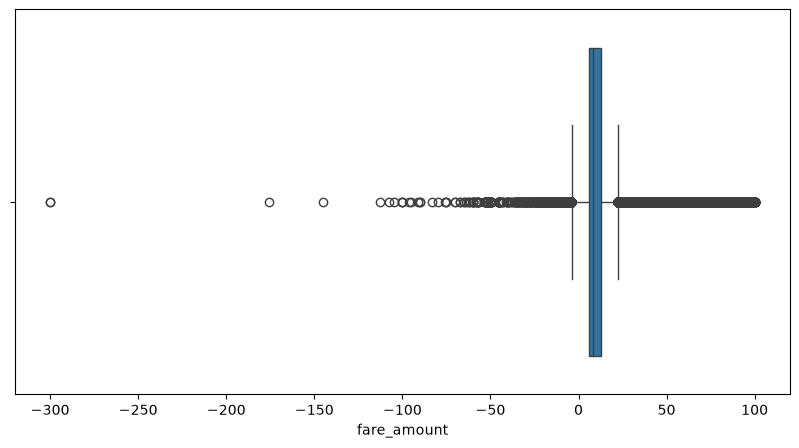

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='fare_amount', data=filtered)
plt.show()

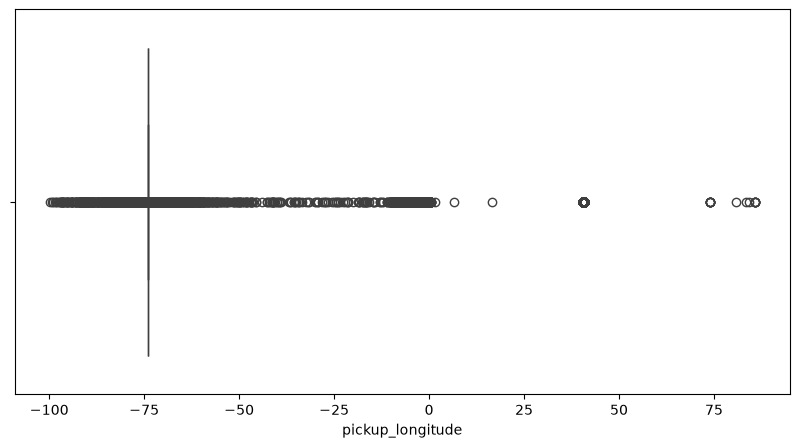

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='pickup_longitude', data=filtered)
plt.show()

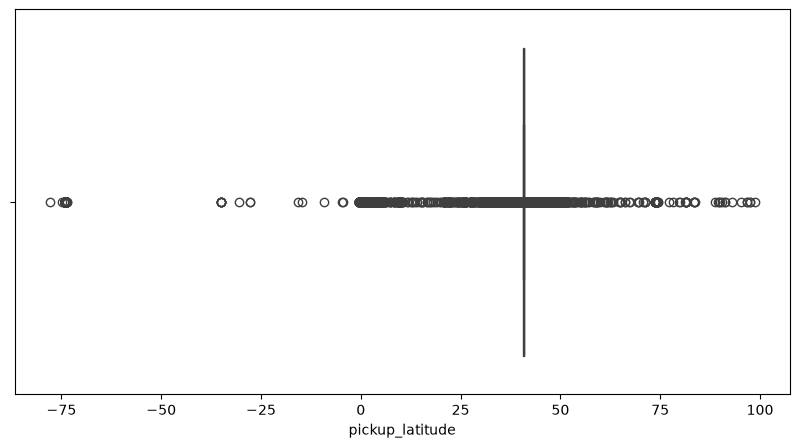

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='pickup_latitude', data=filtered)
plt.show()

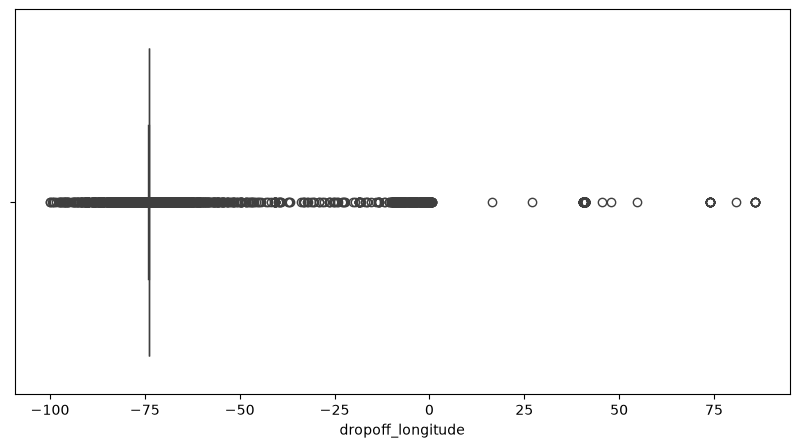

In [13]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='dropoff_longitude', data=filtered)
plt.show()

In [14]:
filtered['passenger_count'].value_counts()

passenger_count
1      38317531
2       8171870
5       3928785
3       2431785
4       1178293
6       1174356
0        195018
208          61
9            22
7            15
8             9
129           2
49            1
34            1
Name: count, dtype: int64